# 01 — EDA & Preprocessing
### UNSW-NB15 Network Intrusion Detection Dataset

Loads, explores, and preprocesses ~2.54M labeled network flow records captured
across two days of synthetic network activity (UNSW Canberra Cyber Range, 2015).

Each record describes a single network connection with 47 features covering protocol
behaviour, packet statistics, and connection timing — labelled as **normal** or one of
**9 attack categories**.

**Outputs**
- `data/processed/traffic_cleaned.parquet` — merged, cleaned dataset for modeling
- PNG figures saved to `data/processed/`

In [1]:
import os
import warnings
import numpy as np
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100})

os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)

## 1. Data Download

In [2]:
# kagglehub caches the dataset after the first download.
# Requires ~/.kaggle/kaggle.json — see README for setup.
dataset_path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")
print(f"Dataset path: {dataset_path}")
print("Files:", sorted(os.listdir(dataset_path)))

Dataset path: /home/username/.cache/kagglehub/datasets/mrwellsdavid/unsw-nb15/versions/1
Files: ['NUSW-NB15_features.csv', 'UNSW-NB15_1.csv', 'UNSW-NB15_2.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_4.csv', 'UNSW-NB15_LIST_EVENTS.csv', 'UNSW_NB15_testing-set.csv', 'UNSW_NB15_training-set.csv']


## 2. Feature Reference

The four raw CSV files (`UNSW-NB15_1.csv` – `_4.csv`) have **no header row**.
Column names are applied manually from `NUSW-NB15_features.csv`, which documents all 49 columns.

In [3]:
features_df = pd.read_csv(
    f"{dataset_path}/NUSW-NB15_features.csv", encoding="ISO-8859-1"
)
features_df.columns = features_df.columns.str.strip()
display(features_df)

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [4]:
COLUMN_NAMES = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur",
    "sbytes", "dbytes", "sttl", "dttl", "sloss", "dloss", "service",
    "sload", "dload", "spkts", "dpkts", "swin", "dwin", "stcpb", "dtcpb",
    "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat",
    "is_sm_ips_ports", "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login",
    "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst", "ct_dst_ltm", "ct_src_ltm",
    "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label",
]
assert len(COLUMN_NAMES) == 49, "Expected 49 columns"
print(f"Defined {len(COLUMN_NAMES)} column names")

Defined 49 column names


## 3. Attack Category Analysis

`UNSW-NB15_LIST_EVENTS.csv` summarises the threat landscape: attack categories,
subcategories, and event counts. This gives a high-level view before loading
the full traffic data.

In [5]:
list_events_df = pd.read_csv(f"{dataset_path}/UNSW-NB15_LIST_EVENTS.csv")
list_events_df["Attack category"] = (
    list_events_df["Attack category"].str.strip().str.lower()
)
list_events_df["Attack subcategory"] = (
    list_events_df["Attack subcategory"].str.strip().str.lower()
)
list_events_df.dropna(subset=["Attack category", "Attack subcategory"], inplace=True)

print("Categories:", sorted(list_events_df["Attack category"].unique()))
print("Subcategories:", list_events_df["Attack subcategory"].nunique())

Categories: ['analysis', 'backdoors', 'dos', 'exploits', 'fuzzers', 'generic', 'reconnaissance', 'shellcode', 'worms']
Subcategories: 103


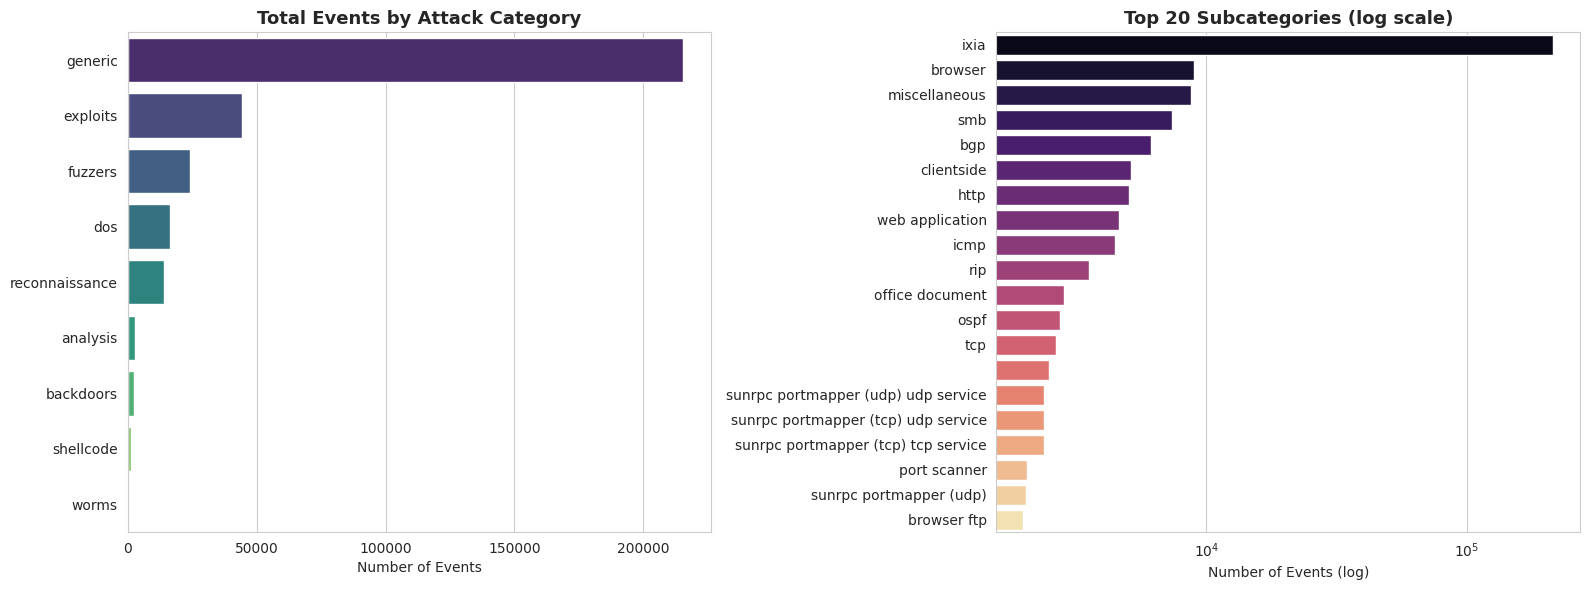

In [6]:
attack_cat_sum = (
    list_events_df.groupby("Attack category")["Number of events"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
attack_sub_sum = (
    list_events_df.groupby("Attack subcategory")["Number of events"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=attack_cat_sum, y="Attack category", x="Number of events",
    ax=axes[0], palette="viridis",
)
axes[0].set_title("Total Events by Attack Category", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Events")
axes[0].set_ylabel("")

sns.barplot(
    data=attack_sub_sum, y="Attack subcategory", x="Number of events",
    ax=axes[1], palette="magma",
)
axes[1].set_xscale("log")
axes[1].set_title("Top 20 Subcategories (log scale)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Events (log)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("data/processed/fig_attack_categories.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Load Traffic Data

In [7]:
dfs = []
for i in range(1, 5):
    filepath = f"{dataset_path}/UNSW-NB15_{i}.csv"
    df = pd.read_csv(filepath, header=None, names=COLUMN_NAMES, low_memory=False)
    print(f"  UNSW-NB15_{i}.csv  →  {df.shape[0]:>9,} rows")
    dfs.append(df)

traffic_df = pd.concat(dfs, ignore_index=True)
print(f"\n  Combined: {traffic_df.shape[0]:,} rows × {traffic_df.shape[1]} columns")

  UNSW-NB15_1.csv  →    700,001 rows
  UNSW-NB15_2.csv  →    700,001 rows
  UNSW-NB15_3.csv  →    700,001 rows
  UNSW-NB15_4.csv  →    440,044 rows

  Combined: 2,540,047 rows × 49 columns


In [8]:
traffic_df["label"] = (
    pd.to_numeric(traffic_df["label"], errors="coerce").fillna(0).astype(int)
)
traffic_df["attack_cat"] = (
    traffic_df["attack_cat"].fillna("normal").str.strip().str.lower()
)

counts = traffic_df["label"].value_counts().sort_index()
print(f"Normal  {counts[0]:>10,}  ({counts[0] / len(traffic_df) * 100:.1f}%)")
print(f"Attack  {counts[1]:>10,}  ({counts[1] / len(traffic_df) * 100:.1f}%)")

Normal   2,218,764  (87.4%)
Attack     321,283  (12.6%)


## 5. Exploratory Data Analysis

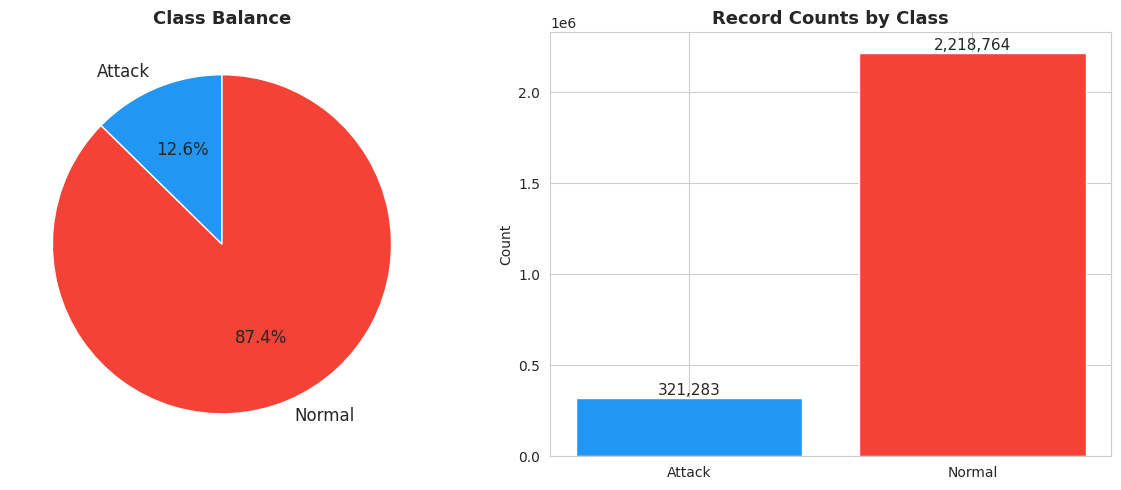

In [9]:
# --- Class Balance ---
label_counts = (
    traffic_df["label"].value_counts().rename({0: "Normal", 1: "Attack"}).sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    label_counts, labels=label_counts.index, autopct="%1.1f%%",
    colors=["#2196F3", "#F44336"], startangle=90, textprops={"fontsize": 12},
)
axes[0].set_title("Class Balance", fontsize=13, fontweight="bold")

bars = axes[1].bar(label_counts.index, label_counts.values, color=["#2196F3", "#F44336"])
axes[1].set_title("Record Counts by Class", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Count")
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height(),
        f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=11,
    )

plt.tight_layout()
plt.savefig("data/processed/fig_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

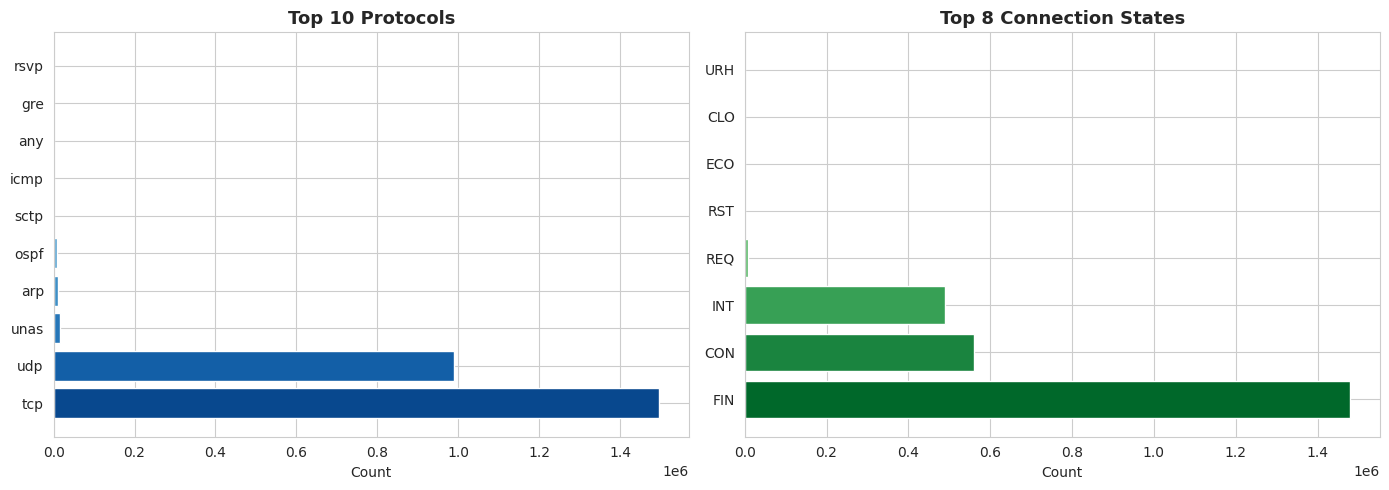

In [10]:
# --- Protocol & State Distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

proto_counts = traffic_df["proto"].value_counts().head(10)
axes[0].barh(proto_counts.index, proto_counts.values,
             color=sns.color_palette("Blues_r", 10))
axes[0].set_title("Top 10 Protocols", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count")

state_counts = traffic_df["state"].value_counts().head(8)
axes[1].barh(state_counts.index, state_counts.values,
             color=sns.color_palette("Greens_r", 8))
axes[1].set_title("Top 8 Connection States", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig("data/processed/fig_protocol_state.png", dpi=150, bbox_inches="tight")
plt.show()

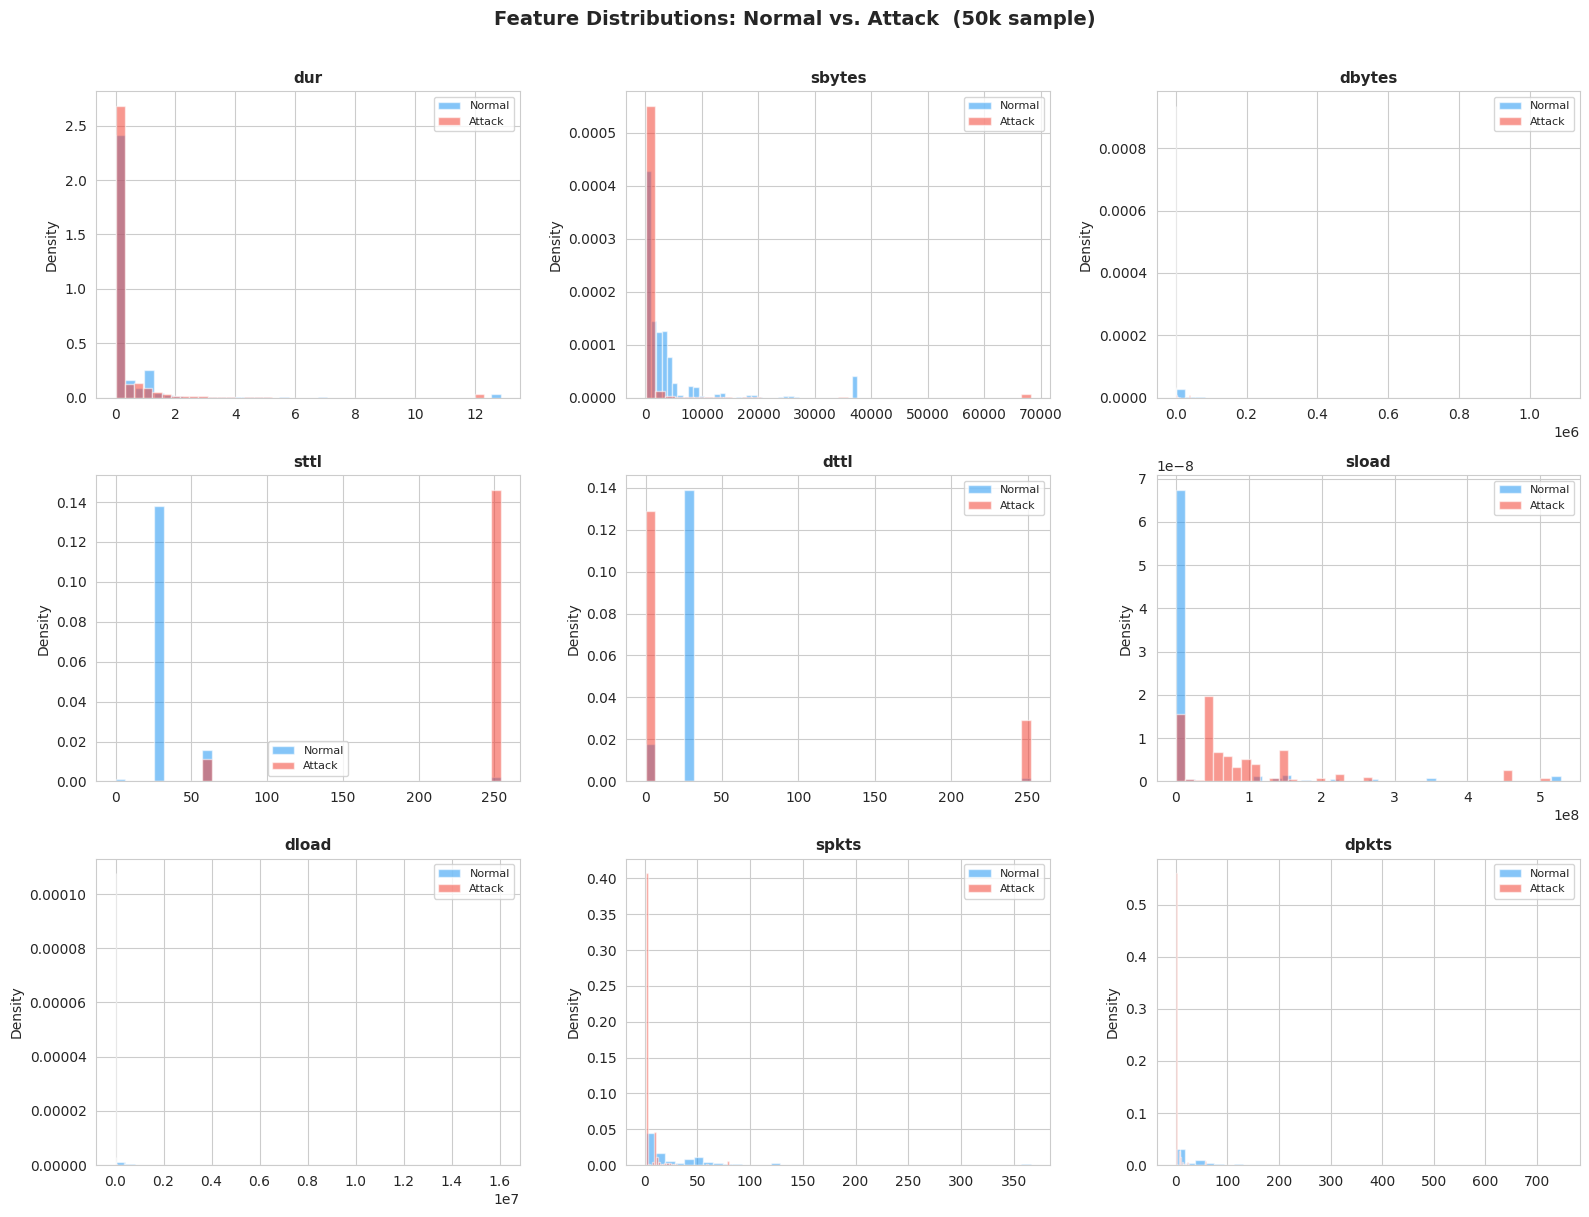

In [11]:
# --- Feature Distributions: Normal vs. Attack ---
KEY_FEATURES = [
    "dur", "sbytes", "dbytes", "sttl", "dttl",
    "sload", "dload", "spkts", "dpkts",
]
sample = traffic_df.sample(n=50_000, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, feat in zip(axes.flatten(), KEY_FEATURES):
    for lbl, color, name in [(0, "#2196F3", "Normal"), (1, "#F44336", "Attack")]:
        data = (
            pd.to_numeric(sample.loc[sample["label"] == lbl, feat], errors="coerce")
            .dropna()
        )
        ax.hist(
            data.clip(upper=data.quantile(0.99)),
            bins=40, alpha=0.55, color=color, label=name, density=True,
        )
    ax.set_title(feat, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylabel("Density")

plt.suptitle(
    "Feature Distributions: Normal vs. Attack  (50k sample)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(
    "data/processed/fig_feature_distributions.png", dpi=150, bbox_inches="tight"
)
plt.show()

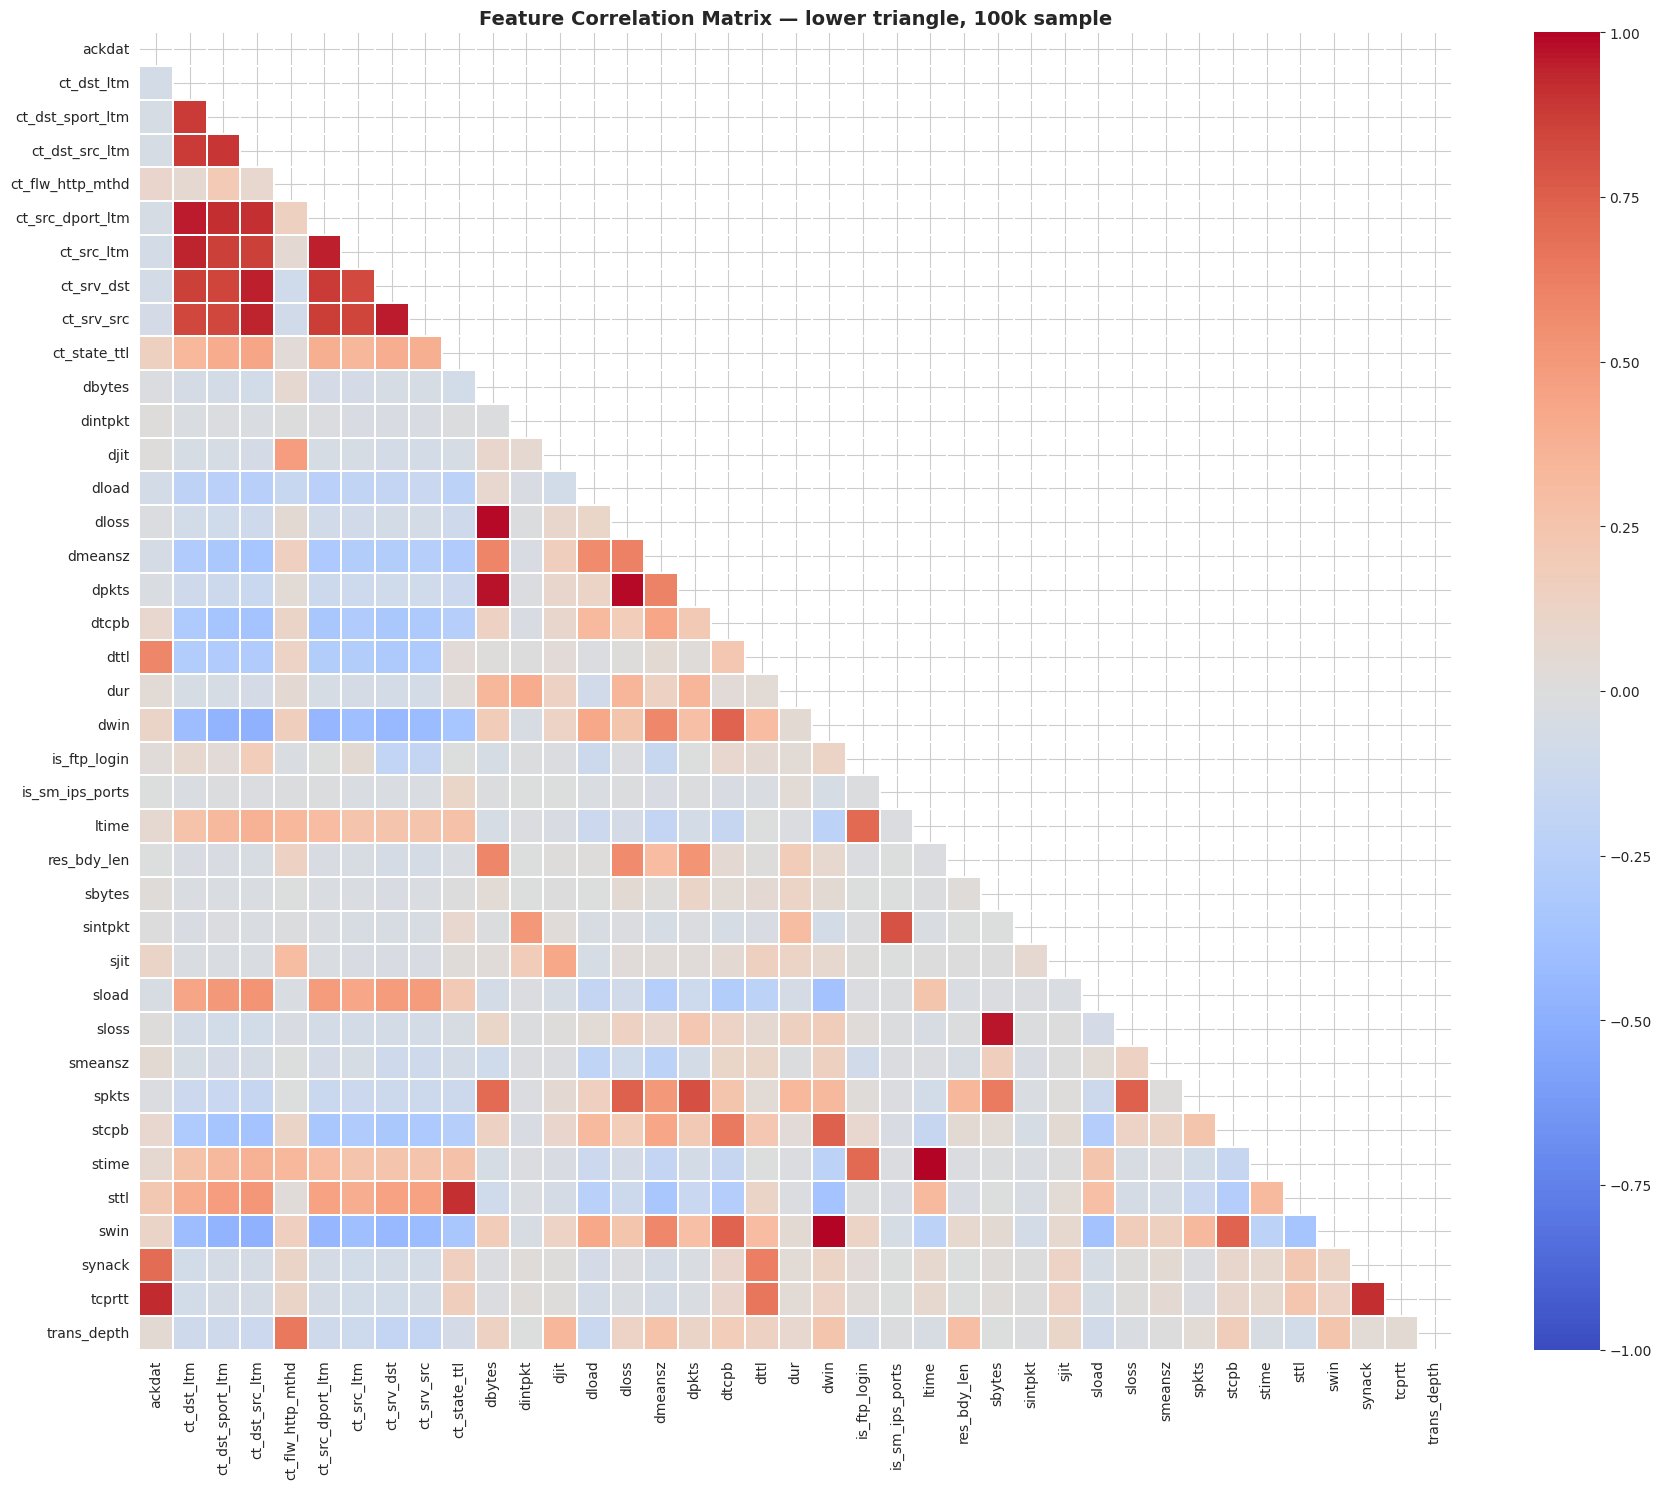

In [12]:
# --- Correlation Heatmap (100k sample for speed) ---
numeric_cols = (
    traffic_df.select_dtypes(include=[np.number])
    .columns.difference(["label"])
    .tolist()
)
corr = (
    traffic_df[numeric_cols]
    .apply(pd.to_numeric, errors="coerce")
    .sample(n=100_000, random_state=42)
    .corr()
)

plt.figure(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot=False,
)
plt.title(
    "Feature Correlation Matrix — lower triangle, 100k sample",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    "data/processed/fig_correlation_heatmap.png", dpi=150, bbox_inches="tight"
)
plt.show()

## 6. Preprocessing & Save

**Dropped columns**
| Column | Reason |
|---|---|
| `srcip`, `dstip` | Raw IP addresses — not generalizable ML features |
| `stime`, `ltime` | Absolute Unix timestamps — not meaningful across capture windows |

Mixed-type columns (`sport`, `dsport`, `ct_flw_http_mthd`, `is_ftp_login`, `ct_ftp_cmd`) are
coerced to numeric; non-parsable values become `NaN`.

Output: `data/processed/traffic_cleaned.parquet`

In [13]:
DROP_COLS = ["srcip", "dstip", "stime", "ltime"]
cleaned = traffic_df.drop(columns=DROP_COLS).copy()

for col in ["proto", "state", "service", "attack_cat"]:
    cleaned[col] = cleaned[col].astype(str).str.strip().str.lower()

mixed_cols = ["sport", "dsport", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd"]
for col in mixed_cols:
    cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

print(f"Cleaned shape  : {cleaned.shape}")
print(f"Missing values : {cleaned.isnull().sum().sum():,}")

out = "data/processed/traffic_cleaned.parquet"
cleaned.to_parquet(out, index=False)
print(f"Saved → {out}  ({os.path.getsize(out) / 1e6:.1f} MB)")

Cleaned shape  : (2540047, 45)
Missing values : 4,208,215
Saved → data/processed/traffic_cleaned.parquet  (183.1 MB)
